<a href="https://colab.research.google.com/github/kabinet557/ksp2026/blob/abhineetavhad/SWIFTJ1727_8_1613.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

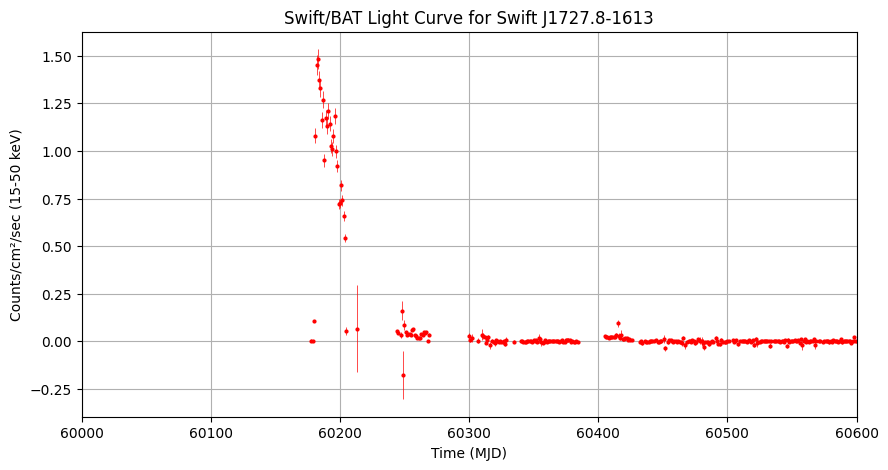

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
url = "https://swift.gsfc.nasa.gov/results/transients/weak/SWIFTJ1727.8-1613.lc.txt"
col_names = [
    "TIME",
    "RATE",
    "ERROR",
    "YEAR",
    "DAY",
    "STAT_ERR",
    "SYS_ERR",
    "DATA_FLAG",
    "TIMEDEL_EXPO",
    "TIMEDEL_CODED",
    "TIMEDEL_DITHERED",
]

data = pd.read_csv(url, sep=r"\s+", comment="#", names=col_names, header=None)

data["TIME"] = pd.to_numeric(data["TIME"], errors="coerce")
data["RATE"] = pd.to_numeric(data["RATE"], errors="coerce")
data["ERROR"] = pd.to_numeric(data["ERROR"], errors="coerce")
data = data.dropna(subset=["TIME", "RATE", "ERROR"])
plt.figure(figsize=(10, 5))
plt.errorbar(
    data["TIME"],
    data["RATE"],
    yerr=data["ERROR"],
    fmt="o",
    color="red",
    ms=2,
    linestyle="None",
    elinewidth=0.5,
)
plt.xlim(60000, 60600)
plt.xlabel("Time (MJD)")
plt.ylabel("Counts/cm²/sec (15-50 keV)")
plt.title("Swift/BAT Light Curve for Swift J1727.8-1613")
plt.grid(True)
plt.show()

In [ ]:
!pip install alerce

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 128.0 MB/s eta 0:00:00


Searching ALeRCE database...
Found ZTF Object ID: ZTF23abaewkl
Fetching light curve data...


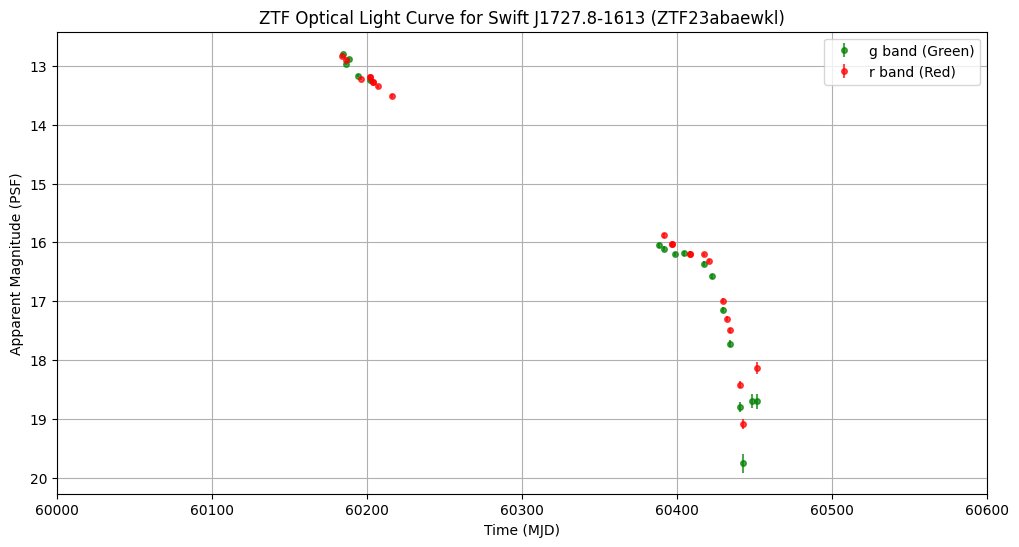

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
from alerce.core import Alerce
alerce = Alerce()
ra, dec = 261.9305, -16.2052

print("Searching ALeRCE database...")
objects = alerce.query_objects(ra=ra, dec=dec, radius=15, format="pandas")

if not objects.empty:
    oid = objects["oid"].iloc[0]
    print(f"Found ZTF Object ID: {oid}")

    print("Fetching light curve data...")
    detections = alerce.query_detections(oid, format="pandas")
    mag_col = "magpsf" if "magpsf" in detections.columns else "mag"
    err_col = "sigmapsf" if "sigmapsf" in detections.columns else "e_mag"
    g_band = detections[detections["fid"] == 1]
    r_band = detections[detections["fid"] == 2]
    plt.figure(figsize=(12, 6))

    if not g_band.empty:
        plt.errorbar(
            g_band["mjd"],
            g_band[mag_col],
            yerr=g_band[err_col],
            fmt="o",
            color="green",
            label="g band (Green)",
            ms=4,
            linestyle="None",
            alpha=0.7,
        )

    if not r_band.empty:
        plt.errorbar(
            r_band["mjd"],
            r_band[mag_col],
            yerr=r_band[err_col],
            fmt="o",
            color="red",
            label="r band (Red)",
            ms=4,
            linestyle="None",
            alpha=0.7,
        )

    plt.gca().invert_yaxis()

    plt.xlim(60000, 60600)

    plt.xlabel("Time (MJD)")
    plt.ylabel("Apparent Magnitude (PSF)")
    plt.title(f"ZTF Optical Light Curve for Swift J1727.8-1613 ({oid})")
    plt.legend()
    plt.grid(True)
    plt.show()

else:
    print("No objects found at these coordinates.")

Fetching ZTF data from ALeRCE...


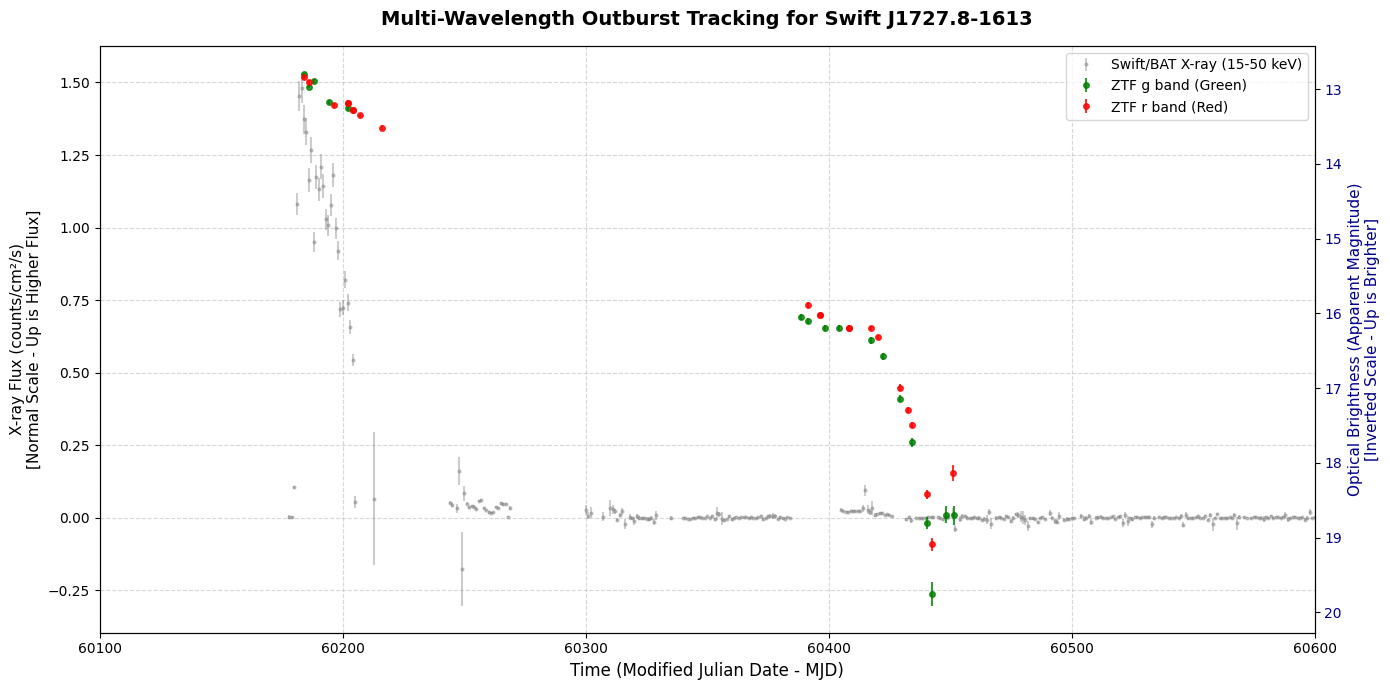

In [ ]:
from alerce.core import Alerce
import matplotlib.pyplot as plt
import pandas as pd

swift_file_path = "https://swift.gsfc.nasa.gov/results/transients/weak/SWIFTJ1727.8-1613.lc.txt"

swift_cols = [
    "TIME",
    "RATE",
    "ERROR",
    "YEAR",
    "DAY",
    "STAT_ERR",
    "SYS_ERR",
    "DATA_FLAG",
]

swift_df = pd.read_csv(
    swift_file_path,
    sep=r"\s+",
    comment="#",
    names=swift_cols,
    usecols=range(8),
    header=None,
)

for col in ["TIME", "RATE", "ERROR"]:
    swift_df[col] = pd.to_numeric(swift_df[col], errors="coerce")
swift_df = swift_df.dropna(subset=["TIME", "RATE", "ERROR"])

print("Fetching ZTF data from ALeRCE...")
alerce = Alerce()
ra, dec = 261.9305, -16.2052
objects = alerce.query_objects(ra=ra, dec=dec, radius=15, format="pandas")
oid = objects["oid"].iloc[0]
ztf_df = alerce.query_detections(oid, format="pandas")
mag_col = "magpsf" if "magpsf" in ztf_df.columns else "mag"
err_col = "sigmapsf" if "sigmapsf" in ztf_df.columns else "e_mag"
g_band = ztf_df[ztf_df["fid"] == 1]
r_band = ztf_df[ztf_df["fid"] == 2]
fig, ax1 = plt.subplots(figsize=(14, 7))
ax1.errorbar(
    swift_df["TIME"],
    swift_df["RATE"],
    yerr=swift_df["ERROR"],
    fmt="o",
    color="gray",
    ms=2,
    alpha=0.4,
    label="Swift/BAT X-ray (15-50 keV)",
)
ax1.set_xlabel("Time (Modified Julian Date - MJD)", fontsize=12)
ax1.set_ylabel(
    "X-ray Flux (counts/cm²/s)\n[Normal Scale - Up is Higher Flux]",
    color="black",
    fontsize=11,
)
ax1.tick_params(axis="y", labelcolor="black")
ax1.grid(True, linestyle="--", alpha=0.5)
ax2 = ax1.twinx()

if not g_band.empty:
    ax2.errorbar(
        g_band["mjd"],
        g_band[mag_col],
        yerr=g_band[err_col],
        fmt="o",
        color="green",
        ms=4,
        alpha=0.8,
        label="ZTF g band (Green)",
    )

if not r_band.empty:
    ax2.errorbar(
        r_band["mjd"],
        r_band[mag_col],
        yerr=r_band[err_col],
        fmt="o",
        color="red",
        ms=4,
        alpha=0.8,
        label="ZTF r band (Red)",
    )

ax2.set_ylabel(
    "Optical Brightness (Apparent Magnitude)\n[Inverted Scale - Up is Brighter]",
    color="darkblue",
    fontsize=11,
)
ax2.tick_params(axis="y", labelcolor="darkblue")
ax2.invert_yaxis()
ax1.set_xlim(60100, 60600)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right", fontsize=10)

plt.title(
    f"Multi-Wavelength Outburst Tracking for Swift J1727.8-1613",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
fig.tight_layout()
plt.show()